# 03_evaluation.ipynb

Setup (Imports + Paths)

In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import pandas as pd

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from tensorflow.keras.preprocessing import image_dataset_from_directory

print("Libraries loaded ✔")

Libraries loaded ✔


In [30]:
if "__file__" in globals():
    BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
else:
    BASE_DIR = os.getcwd()

MODEL_PATH = os.path.join(BASE_DIR, "models", "best_model.keras")
TEST_DIR   = os.path.join(BASE_DIR, "data", "split_data", "test")
HISTORY_PATH = os.path.join(BASE_DIR, "outputs", "training_history.json")

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

Load Model & Test Data

In [31]:
model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded ✔")

test_ds = image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = test_ds.class_names
print("Classes:", class_names)

Model loaded ✔
Found 1693 files belonging to 10 classes.
Classes: ['Corn_(maize)___Common_rust_', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___healthy']


Predictions + Overall Metrics

In [32]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")

print("Accuracy:", acc)
print("Macro F1:", macro_f1)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Accuracy: 0.9822799763733018
Macro F1: 0.9795534416838174

Classification Report:

                               precision    recall  f1-score   support

  Corn_(maize)___Common_rust_       1.00      1.00      1.00       179
Pepper,_bell___Bacterial_spot       1.00      1.00      1.00       150
       Pepper,_bell___healthy       1.00      1.00      1.00       222
        Potato___Early_blight       1.00      0.99      0.99       150
         Potato___Late_blight       0.97      0.97      0.97       150
             Potato___healthy       0.92      1.00      0.96        23
        Tomato___Early_blight       0.99      0.91      0.94       150
         Tomato___Late_blight       0.96      0.98      0.97       287
           Tomato___Leaf_Mold       0.97      0.97      0.97       143
             Tomato___healthy       0.98      1.00      0.99       239

                     accuracy                           0.98      1693
                    macro avg       0.98      0.98      0.98   

Confusion Matrix

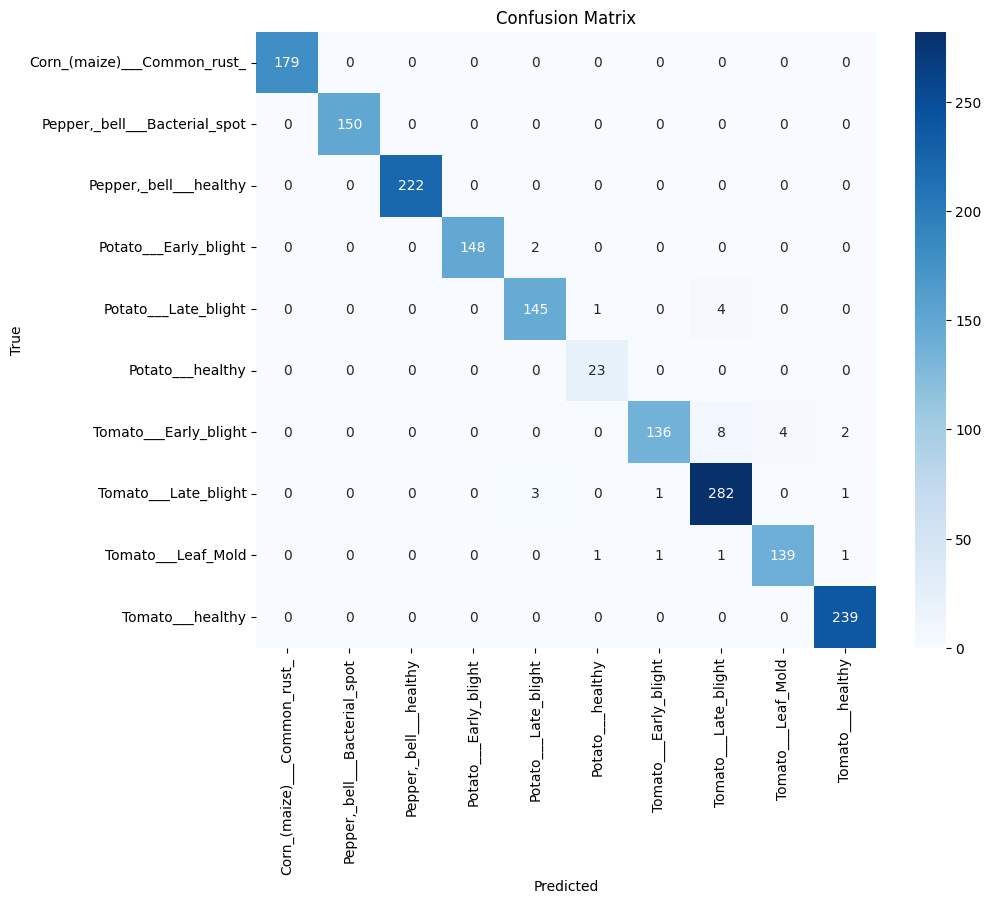

In [70]:
os.makedirs(os.path.join(BASE_DIR, "outputs"), exist_ok=True)

OUTPUT_PATH = os.path.join(BASE_DIR, "outputs", "confusion_matrix.png")

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches="tight")

plt.show()

Training Curves

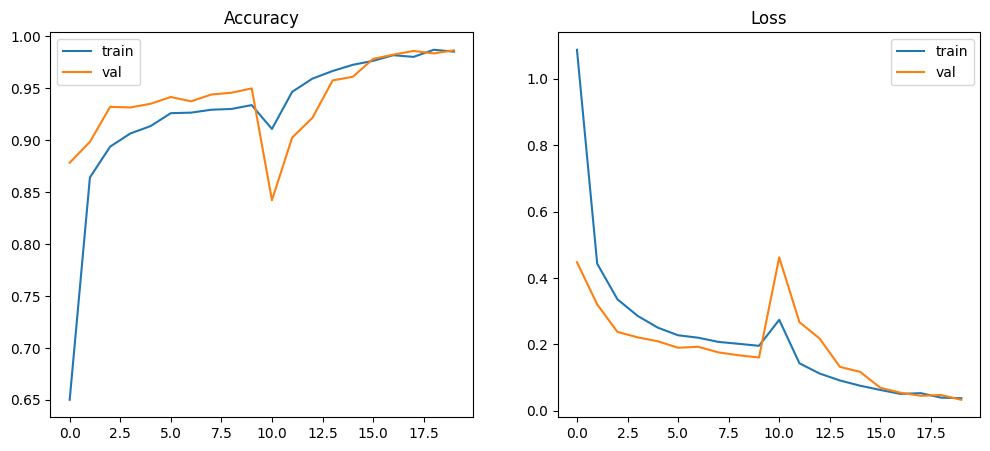

<Figure size 640x480 with 0 Axes>

In [67]:
OUTPUT_PATH = os.path.join(BASE_DIR, "outputs", "training_curves.png")

os.makedirs(os.path.join(BASE_DIR, "outputs"), exist_ok=True)

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history["accuracy"], label="train")
plt.plot(history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history["loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

# save first
plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches="tight")

plt.show()

Quantization (INT8)

In [35]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

tflite_path = os.path.join(BASE_DIR, "models", "model_quantized.tflite")

os.makedirs(os.path.join(BASE_DIR, "models"), exist_ok=True)

with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print("Quantized model saved ✔")

fp32_size = os.path.getsize(MODEL_PATH) / 1e6
int8_size = os.path.getsize(tflite_path) / 1e6

print("FP32 size:", fp32_size, "MB")
print("INT8 size:", int8_size, "MB")
print("Compression ratio:", fp32_size / int8_size)

Saved artifact at '/tmp/tmpncriwbi7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  140291502771856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140291502775696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140291502775312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140291502776272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140291502772432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140291502776656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140291502773200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140291502774352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140291502773392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140291502773968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140291502776

Single Image Prediction Demo

Saving 06040967-7b02-43b5-a3fc-4490a9a7ded6___RS_HL 0508.jpeg to 06040967-7b02-43b5-a3fc-4490a9a7ded6___RS_HL 0508.jpeg
Uploaded: 06040967-7b02-43b5-a3fc-4490a9a7ded6___RS_HL 0508.jpeg


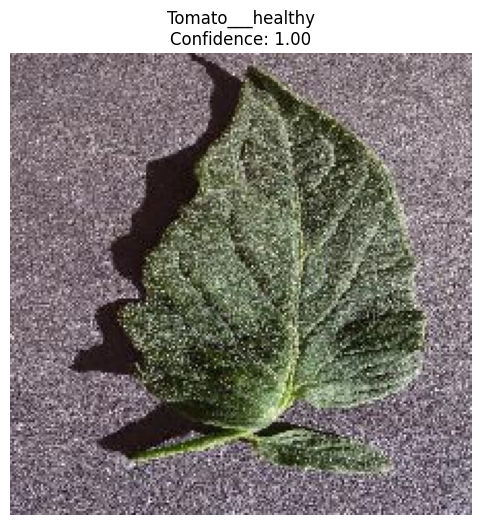


===== RESULT =====
Predicted Class: Tomato___healthy
Confidence: 100.0 %


In [52]:
from google.colab import files

uploaded = files.upload()

img_path = list(uploaded.keys())[0]
print("Uploaded:", img_path)

def predict_uploaded_image(img_path):

    img = tf.keras.utils.load_img(img_path, target_size=IMAGE_SIZE)
    img_array = tf.keras.utils.img_to_array(img)

    input_img = np.expand_dims(img_array, axis=0)

    preds = model.predict(input_img, verbose=0)

    class_idx = np.argmax(preds)
    confidence = np.max(preds)

    label = class_names[class_idx]

    plt.figure(figsize=(6,6))
    plt.imshow(img_array.astype("uint8"))
    plt.axis("off")
    plt.title(f"{label}\nConfidence: {confidence:.2f}")
    plt.show()

    print("\n===== RESULT =====")
    print("Predicted Class:", label)
    print("Confidence:", round(float(confidence)*100, 2), "%")

predict_uploaded_image(img_path)

Saving 07409e2c-a730-4b11-b25e-31025bd63a91___RS_Erly.B 9578.jpeg to 07409e2c-a730-4b11-b25e-31025bd63a91___RS_Erly.B 9578 (1).jpeg
Uploaded: 07409e2c-a730-4b11-b25e-31025bd63a91___RS_Erly.B 9578 (1).jpeg


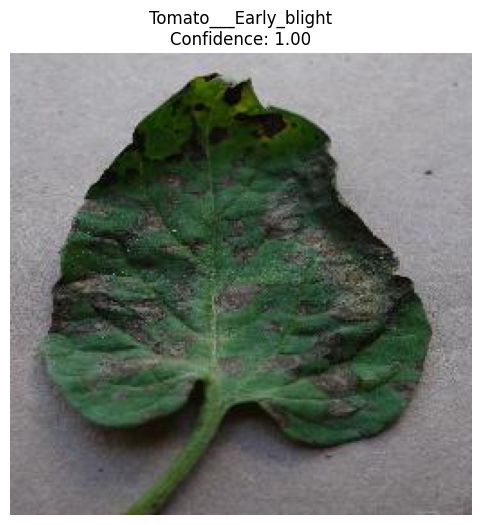


===== TOP PREDICTIONS =====
Tomato___Early_blight : 100.00%
Tomato___Late_blight : 0.00%
Potato___Late_blight : 0.00%

===== FINAL RESULT =====
Predicted Class: Tomato___Early_blight
Confidence: 100.0 %


In [58]:
uploaded = files.upload()

img_path = list(uploaded.keys())[0]
print("Uploaded:", img_path)


def predict_uploaded_image(img_path):

    img = tf.keras.utils.load_img(img_path, target_size=IMAGE_SIZE)
    img_array = tf.keras.utils.img_to_array(img)

    # IMPORTANT: preprocessing (fix stability)
    img_array = tf.keras.applications.mobilenet_v3.preprocess_input(img_array)

    input_img = np.expand_dims(img_array, axis=0)

    preds = model.predict(input_img, verbose=0)

    class_idx = np.argmax(preds)
    confidence = np.max(preds)

    label = class_names[class_idx]

    # ===== Visualization =====
    plt.figure(figsize=(6,6))
    plt.imshow(tf.keras.utils.load_img(img_path))
    plt.axis("off")
    plt.title(f"{label}\nConfidence: {confidence:.2f}")
    plt.show()

    # ===== Extra Explainability =====
    top_k = 3
    top_indices = preds[0].argsort()[-top_k:][::-1]

    print("\n===== TOP PREDICTIONS =====")
    for i in top_indices:
        print(f"{class_names[i]} : {preds[0][i]*100:.2f}%")

    print("\n===== FINAL RESULT =====")
    print("Predicted Class:", label)
    print("Confidence:", round(float(confidence)*100, 2), "%")


predict_uploaded_image(img_path)

In [63]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

df_report = pd.DataFrame(report_dict).transpose()
df_report

,precision,recall,f1-score,support
Corn_(maize)___Common_rust_,1.000000,1.000000,1.000000,179.00000
"Pepper,_bell___Bacterial_spot",1.000000,1.000000,1.000000,150.00000
"Pepper,_bell___healthy",1.000000,1.000000,1.000000,222.00000
Potato___Early_blight,1.000000,0.986667,0.993289,150.00000
Potato___Late_blight,0.966667,0.966667,0.966667,150.00000
Potato___healthy,0.920000,1.000000,0.958333,23.00000
Tomato___Early_blight,0.985507,0.906667,0.944444,150.00000
Tomato___Late_blight,0.955932,0.982578,0.969072,287.00000
Tomato___Leaf_Mold,0.972028,0.972028,0.972028,143.00000
Tomato___healthy,0.983539,1.000000,0.991701,239.00000


In [64]:
print("\n===== CLASS INSIGHT =====")

worst_class = class_names[np.argmin(np.bincount(y_pred == y_true))]
best_class = class_names[np.argmax(np.bincount(y_pred == y_true))]

print("Most Confused Area (approx):", worst_class)
print("Best Performing Pattern:", best_class)


===== CLASS INSIGHT =====
Most Confused Area (approx): Corn_(maize)___Common_rust_
Best Performing Pattern: Pepper,_bell___Bacterial_spot


In [68]:
eval_report = {
    "accuracy": float(acc),
    "macro_f1": float(macro_f1),
    "num_classes": len(class_names),
    "test_samples": len(y_true)
}

OUTPUT_PATH = os.path.join(BASE_DIR, "outputs")
REPORT_PATH = os.path.join(OUTPUT_PATH, "eval_report.json")

os.makedirs(OUTPUT_PATH, exist_ok=True)

with open(REPORT_PATH, "w") as f:
    json.dump(eval_report, f, indent=4)

print("Eval report saved ✔")

Eval report saved ✔


In [62]:
print("\n================ FINAL SUMMARY ================")
print("Dataset Classes:", len(class_names))
print("Model Input Size:", IMAGE_SIZE)
print("Test Samples Evaluated:", len(y_true))
print("Overall Accuracy:", round(acc, 4))
print("Macro F1 Score:", round(macro_f1, 4))

print("\n===== PER-CLASS PERFORMANCE (Top Insight) =====")
print(df_report[["precision", "recall", "f1-score"]].head())

print("\n===== MODEL FILES =====")
print("Best Model Path:", MODEL_PATH)
print("Quantized Model Saved: model_quantized.tflite")
print("History File:", HISTORY_PATH)

print("\n===== KEY INSIGHT =====")
print("Model shows strong performance on majority classes,")
print("with minor confusion between visually similar diseases.")
print("==============================================")


================ FINAL SUMMARY ================
Dataset Classes: 10
Model Input Size: (224, 224)
Test Samples Evaluated: 1693
Overall Accuracy: 0.9823
Macro F1 Score: 0.9796

===== PER-CLASS PERFORMANCE (Top Insight) =====
                               precision    recall  f1-score
Corn_(maize)___Common_rust_     1.000000  1.000000  1.000000
Pepper,_bell___Bacterial_spot   1.000000  1.000000  1.000000
Pepper,_bell___healthy          1.000000  1.000000  1.000000
Potato___Early_blight           1.000000  0.986667  0.993289
Potato___Late_blight            0.966667  0.966667  0.966667

===== MODEL FILES =====
Best Model Path: /content/data/models/best_model.keras
Quantized Model Saved: model_quantized.tflite
History File: /content/outputs/training_history.json

===== KEY INSIGHT =====
Model shows strong performance on majority classes,
with minor confusion between visually similar diseases.
